In [ ]:
%cd /users/alikaan.gueven/AOD_to_nanoAOD/feature_Run3/CMSSW_13_3_0/src/SoftDisplacedVertices/Plotter/testK/notebooks/summary_plots

# !wget -O sus-18-004.csv      "https://www.hepdata.net/download/table/ins1966342/Figure%2010a/1/csv"
# !wget -O sus-20-002_obs.csv  "https://www.hepdata.net/download/table/ins1893826/Figure%209a%20(observed%20limit%20contour)/1/csv"
# !wget -O sus-20-002_exp.csv  "https://www.hepdata.net/download/table/ins1893826/Figure%209a%20(expected%20limit%20contour)/1/csv"
# !wget -O exo-24-033.csv      "https://www.hepdata.net/download/table/ins3081697/Figure%2010c%20(lower)%2C%20exclusion%20curves/1/csv"

/users/alikaan.gueven/AOD_to_nanoAOD/feature_Run3/CMSSW_13_3_0/src/SoftDisplacedVertices/Plotter/testK/notebooks/summary_plots


In [ ]:
import requests
import pandas as pd
import matplotlib.pyplot as plt

In [125]:
sus_20_002_obs = pd.read_csv('sus-20-002_obs.csv', comment="#")
sus_20_002_obs['\\DeltaM [GeV]'] = sus_20_002_obs['m_{stop} [GeV]'] - sus_20_002_obs['m_{LSP} [pb]']

sus_20_002_exp = pd.read_csv('sus-20-002_exp.csv', comment="#")
sus_20_002_exp['\\DeltaM [GeV]'] = sus_20_002_exp['m_{stop} [GeV]'] - sus_20_002_exp['m_{LSP} [pb]']

exo_24_033_obs = pd.read_csv('exo-24-033_obs.csv', comment="#")
exo_24_033_exp = pd.read_csv('exo-24-033_exp.csv', comment="#")

sus_18_004_obs = pd.read_csv('sus-18-004_obs.csv', comment="#")
sus_18_004_exp = pd.read_csv('sus-18-004_exp.csv', comment="#")

In [126]:
# Cross-sections for SUS-18-004

url = "https://twiki.cern.ch/twiki/bin/view/LHCPhysics/SUSYCrossSections13TeVstopsbottom?raw=on"
txt = requests.get(url).text

rows = []
for line in txt.splitlines():
    if line.strip().startswith("|"):
        cols = [c.strip() for c in line.strip("|").split("|")]
        rows.append(cols)

xs_df = pd.DataFrame(rows[1:], columns=rows[0])
xs_df['*Stop / sbottom mass (!GeV)*'] = (
    xs_df['*Stop / sbottom mass (!GeV)*']
    .str.replace(r'[^\d\.]', '', regex=True)   # remove non-numeric
    .astype(float)
)

In [127]:
sus_18_004_obs_merged = pd.merge(left=sus_18_004_obs, right=xs_df, left_on=r'$m_{\tilde{\text{t}}}$ [GeV]', right_on='*Stop / sbottom mass (!GeV)*')
sus_18_004_obs_merged['*Cross section (pb)*'] = sus_18_004_obs_merged['*Cross section (pb)*'].astype(float)
exclude_mask = sus_18_004_obs_merged['95% CL upper limit on the cross section [pb]'] < sus_18_004_obs_merged['*Cross section (pb)*']
sus_18_004_obs_merged['exclude'] = exclude_mask
sus_18_004_obs_merged = sus_18_004_obs_merged[exclude_mask]
sus_18_004_obs_merged = sus_18_004_obs_merged.sort_values([
    r'$m_{\tilde{\text{t}}}$ [GeV]',
    r'$\Delta m (\tilde{\text{t}}, \tilde{\chi}^0_1)$ [GeV]'
])


sus_18_004_obs_max = (
    sus_18_004_obs_merged
    .sort_values(r'$m_{\tilde{\text{t}}}$ [GeV]')
    .groupby(r'$\Delta m (\tilde{\text{t}}, \tilde{\chi}^0_1)$ [GeV]', as_index=False)
    .last()
)

In [128]:
sus_18_004_exp_merged = pd.merge(left=sus_18_004_exp, right=xs_df, left_on=r'$m_{\tilde{\text{t}}}$ [GeV]', right_on='*Stop / sbottom mass (!GeV)*')
sus_18_004_exp_merged['*Cross section (pb)*'] = sus_18_004_exp_merged['*Cross section (pb)*'].astype(float)
exclude_mask = sus_18_004_exp_merged['95% CL upper limit on the cross section [pb]'] < sus_18_004_exp_merged['*Cross section (pb)*']
sus_18_004_exp_merged['exclude'] = exclude_mask
sus_18_004_exp_merged = sus_18_004_exp_merged[exclude_mask]
sus_18_004_exp_merged = sus_18_004_exp_merged.sort_values([
    r'$m_{\tilde{\text{t}}}$ [GeV]',
    r'$\Delta m (\tilde{\text{t}}, \tilde{\chi}^0_1)$ [GeV]'
])


sus_18_004_exp_max = (
    sus_18_004_exp_merged
    .sort_values(r'$m_{\tilde{\text{t}}}$ [GeV]')
    .groupby(r'$\Delta m (\tilde{\text{t}}, \tilde{\chi}^0_1)$ [GeV]', as_index=False)
    .last()
)

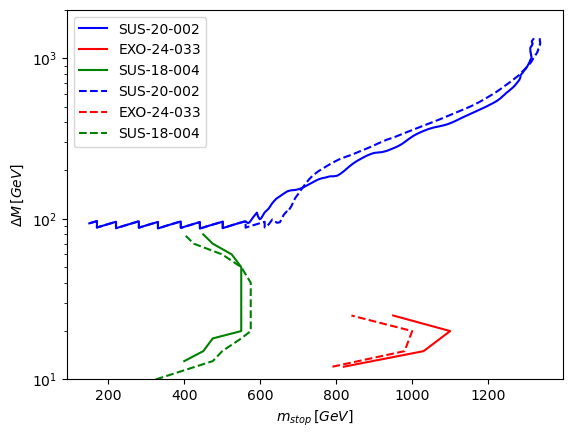

In [129]:
plt.plot(sus_20_002_obs['m_{stop} [GeV]'], sus_20_002_obs['\\DeltaM [GeV]'], 'b-', label='SUS-20-002')
plt.plot(exo_24_033_obs['Observed $m$ excluded at 95%% CL [GeV]'], exo_24_033_obs['$\Delta m$ [GeV]'], 'r-', label='EXO-24-033')
plt.plot(sus_18_004_obs_max[r'$m_{\tilde{\text{t}}}$ [GeV]'], sus_18_004_obs_max[r'$\Delta m (\tilde{\text{t}}, \tilde{\chi}^0_1)$ [GeV]'], 'g-', label='SUS-18-004')

plt.plot(sus_20_002_exp['m_{stop} [GeV]'], sus_20_002_exp['\\DeltaM [GeV]'], 'b--', label='SUS-20-002')
plt.plot(exo_24_033_exp['Median expected $m$ excluded at 95%% CL [GeV]'], exo_24_033_exp['$\Delta m$ [GeV]'], 'r--', label='EXO-24-033')
plt.plot(sus_18_004_exp_max[r'$m_{\tilde{\text{t}}}$ [GeV]'], sus_18_004_exp_max[r'$\Delta m (\tilde{\text{t}}, \tilde{\chi}^0_1)$ [GeV]'], 'g--', label='SUS-18-004')

plt.yscale('log')
plt.xlabel('$m_{stop} \, [GeV]$')
plt.ylabel(r'$\Delta M \, [GeV]$')
plt.ylim(1e1, 2e3)
plt.legend()
plt.show()

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Warning in <TROOT::Append>: Replacing existing TH1: frame (Potential memory leak).


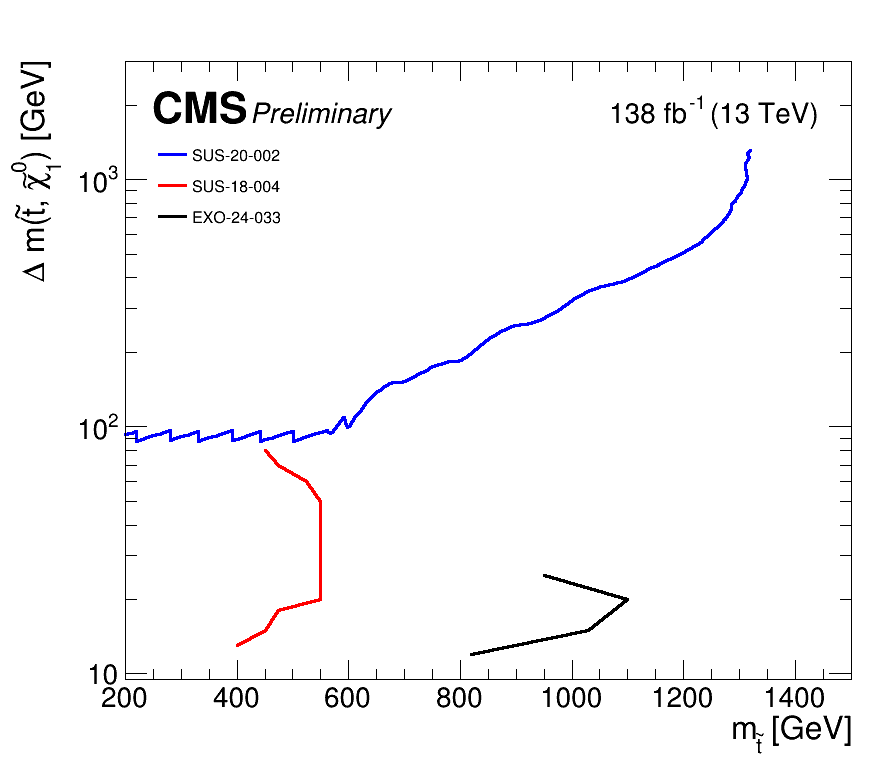

In [33]:
import ROOT
import numpy as np
from array import array

ROOT.gROOT.SetBatch(True)

# --- global style tweaks (CMS-like) ---
ROOT.gStyle.SetOptStat(0)      # remove stat box
ROOT.gStyle.SetPadTickX(1)
ROOT.gStyle.SetPadTickY(1)

def make_graph(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    m = np.isfinite(x) & np.isfinite(y)
    x = x[m]
    y = y[m]
    return ROOT.TGraph(len(x), array("d", x.tolist()), array("d", y.tolist()))

# --- build graphs ---
g_sus20002 = make_graph(
    sus_20_002['m_{stop} [GeV]'],
    sus_20_002['\\DeltaM [GeV]']
)

g_exo24033 = make_graph(
    exo_24_033['Observed $m$ excluded at 95%% CL [GeV]'],
    exo_24_033['$\Delta m$ [GeV]']
)

g_sus18004 = make_graph(
    sus_18_004_max[r'$m_{\tilde{\text{t}}}$ [GeV]'],
    sus_18_004_max[r'$\Delta m (\tilde{\text{t}}, \tilde{\chi}^0_1)$ [GeV]']
)

# --- styles ---
g_sus20002.SetLineColor(ROOT.kBlue)
g_sus20002.SetLineWidth(3)

g_exo24033.SetLineColor(ROOT.kBlack)
g_exo24033.SetLineWidth(3)

g_sus18004.SetLineColor(ROOT.kRed)
g_sus18004.SetLineWidth(3)

# --- canvas ---
c = ROOT.TCanvas("c","",900,800)
c.SetLogy()

# Fix axis clipping
c.SetLeftMargin(0.14)
c.SetRightMargin(0.05)
c.SetTopMargin(0.08)
c.SetBottomMargin(0.12)

# --- frame ---
frame = ROOT.TH1F("frame","",100,200,1500)
frame.SetMinimum(10)
frame.SetMaximum(2000)

frame.GetXaxis().SetTitle("m_{#tilde{t}} [GeV]")
frame.GetYaxis().SetTitle("#Delta m(#tilde{t}, #tilde{#chi}^{0}_{1}) [GeV]")

frame.GetXaxis().SetTitleSize(0.045)
frame.GetYaxis().SetTitleSize(0.045)

frame.GetXaxis().SetLabelSize(0.04)
frame.GetYaxis().SetLabelSize(0.04)

frame.GetYaxis().SetTitleOffset(1.4)   # helps visibility


frame.SetMinimum(9.5)
frame.SetMaximum(3000)
frame.Draw()

# --- draw graphs ---
g_sus20002.Draw("L SAME")
g_exo24033.Draw("L SAME")
g_sus18004.Draw("L SAME")

# --- legend moved right ---
leg = ROOT.TLegend(0.17,0.70,0.35,0.82)
leg.SetBorderSize(0)
leg.SetFillColor(ROOT.kWhite)

leg.AddEntry(g_sus20002,"SUS-20-002","l")
leg.AddEntry(g_sus18004,"SUS-18-004","l")
leg.AddEntry(g_exo24033,"EXO-24-033","l")

leg.Draw()

# --- CMS labels ---
latex = ROOT.TLatex()
latex.SetNDC()

latex.SetTextFont(62)
latex.SetTextSize(0.06)
latex.DrawLatex(0.17,0.84,"CMS")

latex.SetTextFont(52)
latex.SetTextSize(0.04)
latex.DrawLatex(0.28,0.84,"Preliminary")

latex.SetTextFont(42)
latex.SetTextSize(0.04)
latex.DrawLatex(0.68,0.84,"138 fb^{-1} (13 TeV)")

c.RedrawAxis()
c.Update()
c.Draw()

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Warning in <TROOT::Append>: Replacing existing TH1: frame (Potential memory leak).


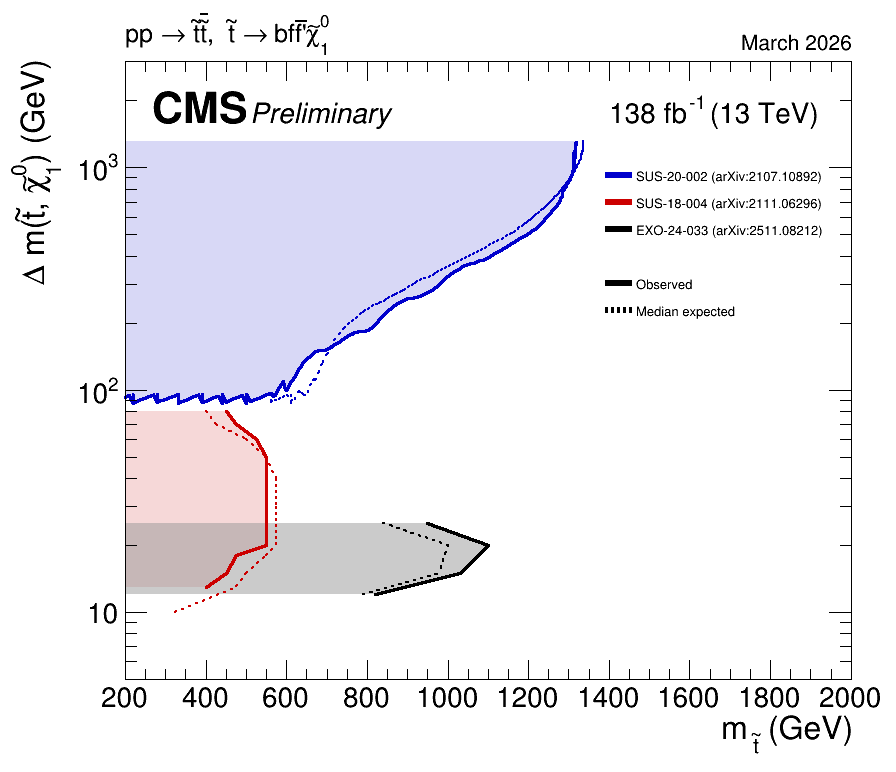

In [149]:
import ROOT
import numpy as np
from array import array

ROOT.gROOT.SetBatch(True)

# --- global style tweaks (CMS-like) ---
ROOT.gStyle.SetOptStat(0)
ROOT.gStyle.SetPadTickX(1)
ROOT.gStyle.SetPadTickY(1)

def make_graph(x, y, sort=2):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    m = np.isfinite(x) & np.isfinite(y)
    x = x[m]
    y = y[m]

    if sort == 2:
        order = np.argsort(y)  # important for proper polygon
    elif sort == 1:
        order = np.argsort(x)  # important for proper polygon

    x = x[order]
    y = y[order]

    return ROOT.TGraph(len(x), array("d", x.tolist()), array("d", y.tolist()))

def make_left_exclusion(graph, xmin):
    """
    Create filled polygon for region LEFT of curve.
    """
    n = graph.GetN()

    xs = [graph.GetPointX(i) for i in range(n)]
    ys = [graph.GetPointY(i) for i in range(n)]

    x0, y0 = xs[0], ys[0]
    x1, y1 = xs[-1], ys[-1]

    poly_x = [xmin, x0] + xs + [xmin, xmin]
    poly_y = [y0,   y0] + ys + [y1,   y0]

    return ROOT.TGraph(len(poly_x),
                       array("d", poly_x),
                       array("d", poly_y))


# --- build graphs ---
g_sus20002_obs = make_graph(
    sus_20_002_obs['m_{stop} [GeV]'],
    sus_20_002_obs['\\DeltaM [GeV]'],
    sort=1
)

g_exo24033_obs = make_graph(
    exo_24_033_obs['Observed $m$ excluded at 95%% CL [GeV]'],
    exo_24_033_obs['$\Delta m$ [GeV]'],
    sort=2
)

g_sus18004_obs = make_graph(
    sus_18_004_obs_max[r'$m_{\tilde{\text{t}}}$ [GeV]'],
    sus_18_004_obs_max[r'$\Delta m (\tilde{\text{t}}, \tilde{\chi}^0_1)$ [GeV]'],
    sort=2
)

g_sus20002_exp = make_graph(
    sus_20_002_exp['m_{stop} [GeV]'],
    sus_20_002_exp['\\DeltaM [GeV]'],
    sort=1
)

g_exo24033_exp = make_graph(
    exo_24_033_exp['Median expected $m$ excluded at 95%% CL [GeV]'],
    exo_24_033_exp['$\Delta m$ [GeV]'],
    sort=2
)

g_sus18004_exp = make_graph(
    sus_18_004_exp_max[r'$m_{\tilde{\text{t}}}$ [GeV]'],
    sus_18_004_exp_max[r'$\Delta m (\tilde{\text{t}}, \tilde{\chi}^0_1)$ [GeV]'],
    sort=2
)



# --- style ---
g_sus20002_obs.SetLineColor(ROOT.kBlue+1)
g_sus20002_obs.SetLineWidth(3)

g_exo24033_obs.SetLineColor(ROOT.kBlack)
g_exo24033_obs.SetLineWidth(3)

g_sus18004_obs.SetLineColor(ROOT.kRed+1)
g_sus18004_obs.SetLineWidth(3)

g_sus20002_exp.SetLineColor(ROOT.kBlue+1)
g_sus20002_exp.SetLineWidth(2)
g_sus20002_exp.SetLineStyle(2)

g_exo24033_exp.SetLineColor(ROOT.kBlack)
g_exo24033_exp.SetLineWidth(2)
g_exo24033_exp.SetLineStyle(2)

g_sus18004_exp.SetLineColor(ROOT.kRed+1)
g_sus18004_exp.SetLineWidth(2)
g_sus18004_exp.SetLineStyle(2)


# --- canvas ---
c = ROOT.TCanvas("c","",900,800)
c.SetLogy()

c.SetLeftMargin(0.14)
c.SetRightMargin(0.05)
c.SetTopMargin(0.08)
c.SetBottomMargin(0.12)

xmin, xmax = 200, 2000
ymin, ymax = 5, 3000

# --- frame ---
frame = ROOT.TH1F("frame","",100,xmin,xmax)
frame.SetMinimum(ymin)
frame.SetMaximum(ymax)

frame.GetXaxis().SetTitle("m_{ #tilde{t}} (GeV)")
frame.GetYaxis().SetTitle("#Delta m(#tilde{t}, #tilde{#chi}^{0}_{1}) (GeV)")

frame.GetXaxis().SetTitleSize(0.045)
frame.GetYaxis().SetTitleSize(0.045)
frame.GetXaxis().SetLabelSize(0.04)
frame.GetYaxis().SetLabelSize(0.04)

frame.GetYaxis().SetTitleOffset(1.4)

frame.Draw()


# --- shaded exclusion regions ---
h_sus20002 = make_left_exclusion(g_sus20002_obs, xmin)
h_sus20002.SetFillColorAlpha(ROOT.kBlue+1,0.15)
h_sus20002.SetLineWidth(0)
h_sus20002.Draw("F SAME")

h_sus18004 = make_left_exclusion(g_sus18004_obs, xmin)
h_sus18004.SetFillColorAlpha(ROOT.kRed+1,0.15)
h_sus18004.SetLineWidth(0)
h_sus18004.Draw("F SAME")

h_exo24033 = make_left_exclusion(g_exo24033_obs, xmin)
# h_exo24033.SetFillStyle(3354)   # hatched
h_exo24033.SetFillColorAlpha(ROOT.kGray+1, 0.50)
h_exo24033.SetLineWidth(0)
h_exo24033.Draw("F SAME")


# --- draw curves ---
g_sus20002_obs.Draw("L SAME")
g_sus18004_obs.Draw("L SAME")
g_exo24033_obs.Draw("L SAME")

# --- draw curves ---
g_sus20002_exp.Draw("L SAME")
g_sus18004_exp.Draw("L SAME")
g_exo24033_exp.Draw("L SAME")


# --- legend ---
# dummy objects for legend
leg_sus20002 = ROOT.TLine()
leg_sus20002.SetLineColor(ROOT.kBlue+1)
leg_sus20002.SetLineWidth(6)

leg_sus18004 = ROOT.TLine()
leg_sus18004.SetLineColor(ROOT.kRed+1)
leg_sus18004.SetLineWidth(6)

leg_exo24033 = ROOT.TLine()
leg_exo24033.SetLineColor(ROOT.kBlack)
leg_exo24033.SetLineWidth(6)

leg_obs = ROOT.TLine()
leg_obs.SetLineColor(ROOT.kBlack)
leg_obs.SetLineWidth(6)
leg_obs.SetLineStyle(1)

leg_exp = ROOT.TLine()
leg_exp.SetLineColor(ROOT.kBlack)
leg_exp.SetLineWidth(6)
leg_exp.SetLineStyle(2)

# legend
leg = ROOT.TLegend(0.67,0.58,0.94,0.79)
leg.SetBorderSize(0)
leg.SetFillColor(ROOT.kWhite)

leg.AddEntry(leg_sus20002, "SUS-20-002 (arXiv:2107.10892)", "l")
leg.AddEntry(leg_sus18004, "SUS-18-004 (arXiv:2111.06296)", "l")
leg.AddEntry(leg_exo24033, "EXO-24-033 (arXiv:2511.08212)", "l")

# spacer
leg.AddEntry(0, "", "")

# line-style explanation
leg.AddEntry(leg_obs, "Observed", "l")
leg.AddEntry(leg_exp, "Median expected", "l")



leg.SetMargin(0.15)
leg.Draw()


# --- CMS labels ---
latex = ROOT.TLatex()
latex.SetNDC()

latex.SetTextFont(62)
latex.SetTextSize(0.06)
latex.DrawLatex(0.17,0.84,"CMS")

latex.SetTextFont(52)
latex.SetTextSize(0.04)
latex.DrawLatex(0.28,0.84,"Preliminary")

latex.SetTextFont(42)
latex.SetTextSize(0.04)
latex.DrawLatex(0.68,0.84,"138 fb^{-1} (13 TeV)")

latex.SetTextFont(42)
latex.SetTextSize(0.03)
latex.DrawLatex(0.828,0.935,"March 2026")

latex.SetTextFont(42)
latex.SetTextSize(0.035)
latex.DrawLatex(0.14,0.945,"pp #rightarrow #tilde{t}#bar{#tilde{t}},  #tilde{t} #rightarrow bf#bar{f'}#tilde{#chi}^{0}_{1}")


c.RedrawAxis()
c.Update()
c.Draw()

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Warning in <TROOT::Append>: Replacing existing TH1: frame (Potential memory leak).


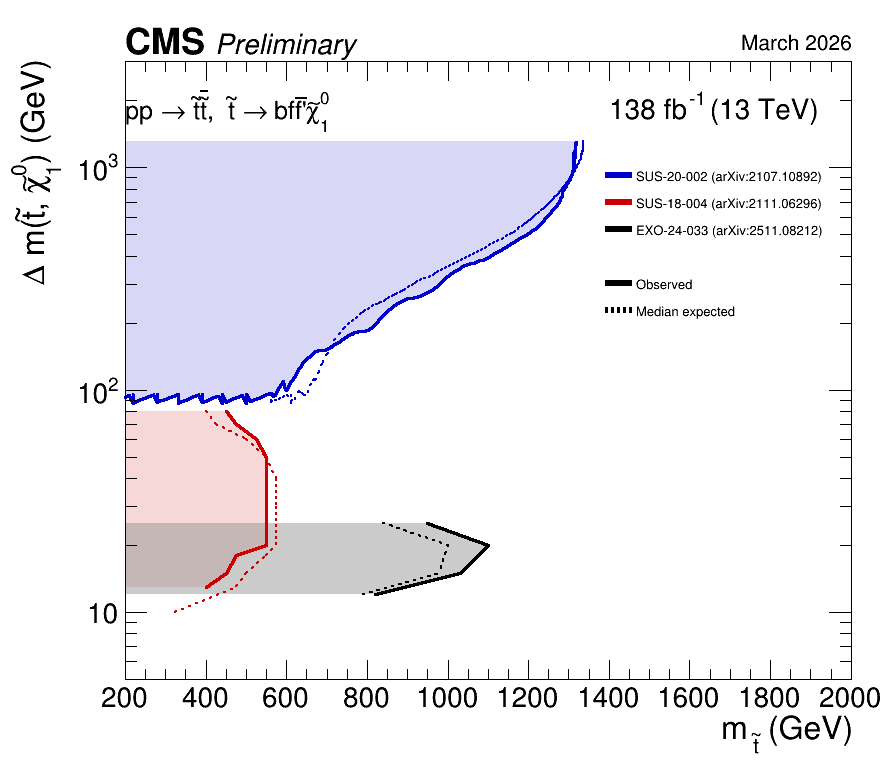

In [157]:
import ROOT
import numpy as np
from array import array

ROOT.gROOT.SetBatch(True)

# --- global style tweaks (CMS-like) ---
ROOT.gStyle.SetOptStat(0)
ROOT.gStyle.SetPadTickX(1)
ROOT.gStyle.SetPadTickY(1)

def make_graph(x, y, sort=2):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    m = np.isfinite(x) & np.isfinite(y)
    x = x[m]
    y = y[m]

    if sort == 2:
        order = np.argsort(y)  # important for proper polygon
    elif sort == 1:
        order = np.argsort(x)  # important for proper polygon

    x = x[order]
    y = y[order]

    return ROOT.TGraph(len(x), array("d", x.tolist()), array("d", y.tolist()))

def make_left_exclusion(graph, xmin):
    """
    Create filled polygon for region LEFT of curve.
    """
    n = graph.GetN()

    xs = [graph.GetPointX(i) for i in range(n)]
    ys = [graph.GetPointY(i) for i in range(n)]

    x0, y0 = xs[0], ys[0]
    x1, y1 = xs[-1], ys[-1]

    poly_x = [xmin, x0] + xs + [xmin, xmin]
    poly_y = [y0,   y0] + ys + [y1,   y0]

    return ROOT.TGraph(len(poly_x),
                       array("d", poly_x),
                       array("d", poly_y))


# --- build graphs ---
g_sus20002_obs = make_graph(
    sus_20_002_obs['m_{stop} [GeV]'],
    sus_20_002_obs['\\DeltaM [GeV]'],
    sort=1
)

g_exo24033_obs = make_graph(
    exo_24_033_obs['Observed $m$ excluded at 95%% CL [GeV]'],
    exo_24_033_obs['$\Delta m$ [GeV]'],
    sort=2
)

g_sus18004_obs = make_graph(
    sus_18_004_obs_max[r'$m_{\tilde{\text{t}}}$ [GeV]'],
    sus_18_004_obs_max[r'$\Delta m (\tilde{\text{t}}, \tilde{\chi}^0_1)$ [GeV]'],
    sort=2
)

g_sus20002_exp = make_graph(
    sus_20_002_exp['m_{stop} [GeV]'],
    sus_20_002_exp['\\DeltaM [GeV]'],
    sort=1
)

g_exo24033_exp = make_graph(
    exo_24_033_exp['Median expected $m$ excluded at 95%% CL [GeV]'],
    exo_24_033_exp['$\Delta m$ [GeV]'],
    sort=2
)

g_sus18004_exp = make_graph(
    sus_18_004_exp_max[r'$m_{\tilde{\text{t}}}$ [GeV]'],
    sus_18_004_exp_max[r'$\Delta m (\tilde{\text{t}}, \tilde{\chi}^0_1)$ [GeV]'],
    sort=2
)



# --- style ---
g_sus20002_obs.SetLineColor(ROOT.kBlue+1)
g_sus20002_obs.SetLineWidth(3)

g_exo24033_obs.SetLineColor(ROOT.kBlack)
g_exo24033_obs.SetLineWidth(3)

g_sus18004_obs.SetLineColor(ROOT.kRed+1)
g_sus18004_obs.SetLineWidth(3)

g_sus20002_exp.SetLineColor(ROOT.kBlue+1)
g_sus20002_exp.SetLineWidth(2)
g_sus20002_exp.SetLineStyle(2)

g_exo24033_exp.SetLineColor(ROOT.kBlack)
g_exo24033_exp.SetLineWidth(2)
g_exo24033_exp.SetLineStyle(2)

g_sus18004_exp.SetLineColor(ROOT.kRed+1)
g_sus18004_exp.SetLineWidth(2)
g_sus18004_exp.SetLineStyle(2)


# --- canvas ---
c = ROOT.TCanvas("c","",900,800)
c.SetLogy()

c.SetLeftMargin(0.14)
c.SetRightMargin(0.05)
c.SetTopMargin(0.08)
c.SetBottomMargin(0.12)

xmin, xmax = 200, 2000
ymin, ymax = 5, 3000

# --- frame ---
frame = ROOT.TH1F("frame","",100,xmin,xmax)
frame.SetMinimum(ymin)
frame.SetMaximum(ymax)

frame.GetXaxis().SetTitle("m_{ #tilde{t}} (GeV)")
frame.GetYaxis().SetTitle("#Delta m(#tilde{t}, #tilde{#chi}^{0}_{1}) (GeV)")

frame.GetXaxis().SetTitleSize(0.045)
frame.GetYaxis().SetTitleSize(0.045)
frame.GetXaxis().SetLabelSize(0.04)
frame.GetYaxis().SetLabelSize(0.04)

frame.GetYaxis().SetTitleOffset(1.4)

frame.Draw()


# --- shaded exclusion regions ---
h_sus20002 = make_left_exclusion(g_sus20002_obs, xmin)
h_sus20002.SetFillColorAlpha(ROOT.kBlue+1,0.15)
h_sus20002.SetLineWidth(0)
h_sus20002.Draw("F SAME")

h_sus18004 = make_left_exclusion(g_sus18004_obs, xmin)
h_sus18004.SetFillColorAlpha(ROOT.kRed+1,0.15)
h_sus18004.SetLineWidth(0)
h_sus18004.Draw("F SAME")

h_exo24033 = make_left_exclusion(g_exo24033_obs, xmin)
# h_exo24033.SetFillStyle(3354)   # hatched
h_exo24033.SetFillColorAlpha(ROOT.kGray+1, 0.50)
h_exo24033.SetLineWidth(0)
h_exo24033.Draw("F SAME")


# --- draw curves ---
g_sus20002_obs.Draw("L SAME")
g_sus18004_obs.Draw("L SAME")
g_exo24033_obs.Draw("L SAME")

# --- draw curves ---
g_sus20002_exp.Draw("L SAME")
g_sus18004_exp.Draw("L SAME")
g_exo24033_exp.Draw("L SAME")


# --- legend ---
# dummy objects for legend
leg_sus20002 = ROOT.TLine()
leg_sus20002.SetLineColor(ROOT.kBlue+1)
leg_sus20002.SetLineWidth(6)

leg_sus18004 = ROOT.TLine()
leg_sus18004.SetLineColor(ROOT.kRed+1)
leg_sus18004.SetLineWidth(6)

leg_exo24033 = ROOT.TLine()
leg_exo24033.SetLineColor(ROOT.kBlack)
leg_exo24033.SetLineWidth(6)

leg_obs = ROOT.TLine()
leg_obs.SetLineColor(ROOT.kBlack)
leg_obs.SetLineWidth(6)
leg_obs.SetLineStyle(1)

leg_exp = ROOT.TLine()
leg_exp.SetLineColor(ROOT.kBlack)
leg_exp.SetLineWidth(6)
leg_exp.SetLineStyle(2)

# legend
leg = ROOT.TLegend(0.67,0.58,0.94,0.79)
leg.SetBorderSize(0)
leg.SetFillColor(ROOT.kWhite)

leg.AddEntry(leg_sus20002, "SUS-20-002 (arXiv:2107.10892)", "l")
leg.AddEntry(leg_sus18004, "SUS-18-004 (arXiv:2111.06296)", "l")
leg.AddEntry(leg_exo24033, "EXO-24-033 (arXiv:2511.08212)", "l")

# spacer
leg.AddEntry(0, "", "")

# line-style explanation
leg.AddEntry(leg_obs, "Observed", "l")
leg.AddEntry(leg_exp, "Median expected", "l")



leg.SetMargin(0.15)
leg.Draw()


# --- CMS labels ---
latex = ROOT.TLatex()
latex.SetNDC()

latex.SetTextFont(62)
latex.SetTextSize(0.05)
latex.DrawLatex(0.14,0.93,"CMS")

latex.SetTextFont(52)
latex.SetTextSize(0.04)
latex.DrawLatex(0.24,0.93,"Preliminary")

latex.SetTextFont(42)
latex.SetTextSize(0.04)
latex.DrawLatex(0.68,0.845,"138 fb^{-1} (13 TeV)")

latex.SetTextFont(42)
latex.SetTextSize(0.03)
latex.DrawLatex(0.828,0.935,"March 2026")

latex.SetTextFont(42)
latex.SetTextSize(0.035)
latex.DrawLatex(0.14,0.845,"pp #rightarrow #tilde{t}#bar{#tilde{t}},  #tilde{t} #rightarrow bf#bar{f'}#tilde{#chi}^{0}_{1}")


c.RedrawAxis()
c.Update()
c.Draw()

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Warning in <TROOT::Append>: Replacing existing TH1: frame (Potential memory leak).


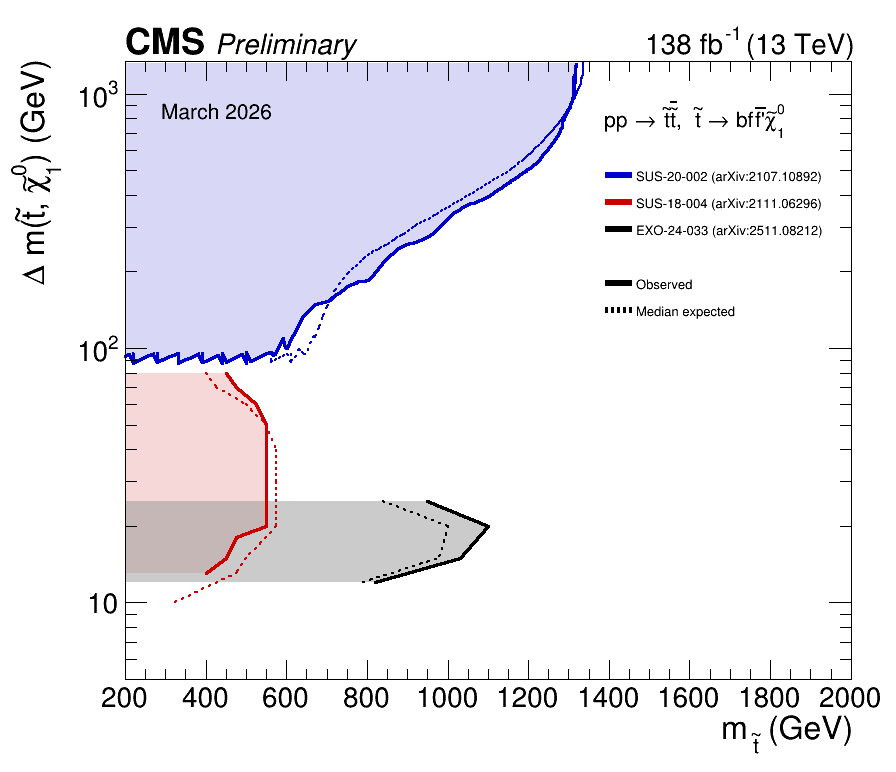

In [177]:
import ROOT
import numpy as np
from array import array

ROOT.gROOT.SetBatch(True)

# --- global style tweaks (CMS-like) ---
ROOT.gStyle.SetOptStat(0)
ROOT.gStyle.SetPadTickX(1)
ROOT.gStyle.SetPadTickY(1)

def make_graph(x, y, sort=2):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    m = np.isfinite(x) & np.isfinite(y)
    x = x[m]
    y = y[m]

    if sort == 2:
        order = np.argsort(y)  # important for proper polygon
    elif sort == 1:
        order = np.argsort(x)  # important for proper polygon

    x = x[order]
    y = y[order]

    return ROOT.TGraph(len(x), array("d", x.tolist()), array("d", y.tolist()))

def make_left_exclusion(graph, xmin):
    """
    Create filled polygon for region LEFT of curve.
    """
    n = graph.GetN()

    xs = [graph.GetPointX(i) for i in range(n)]
    ys = [graph.GetPointY(i) for i in range(n)]

    x0, y0 = xs[0], ys[0]
    x1, y1 = xs[-1], ys[-1]

    poly_x = [xmin, x0] + xs + [xmin, xmin]
    poly_y = [y0,   y0] + ys + [y1,   y0]

    return ROOT.TGraph(len(poly_x),
                       array("d", poly_x),
                       array("d", poly_y))


# --- build graphs ---
g_sus20002_obs = make_graph(
    sus_20_002_obs['m_{stop} [GeV]'],
    sus_20_002_obs['\\DeltaM [GeV]'],
    sort=1
)

g_exo24033_obs = make_graph(
    exo_24_033_obs['Observed $m$ excluded at 95%% CL [GeV]'],
    exo_24_033_obs['$\Delta m$ [GeV]'],
    sort=2
)

g_sus18004_obs = make_graph(
    sus_18_004_obs_max[r'$m_{\tilde{\text{t}}}$ [GeV]'],
    sus_18_004_obs_max[r'$\Delta m (\tilde{\text{t}}, \tilde{\chi}^0_1)$ [GeV]'],
    sort=2
)

g_sus20002_exp = make_graph(
    sus_20_002_exp['m_{stop} [GeV]'],
    sus_20_002_exp['\\DeltaM [GeV]'],
    sort=1
)

g_exo24033_exp = make_graph(
    exo_24_033_exp['Median expected $m$ excluded at 95%% CL [GeV]'],
    exo_24_033_exp['$\Delta m$ [GeV]'],
    sort=2
)

g_sus18004_exp = make_graph(
    sus_18_004_exp_max[r'$m_{\tilde{\text{t}}}$ [GeV]'],
    sus_18_004_exp_max[r'$\Delta m (\tilde{\text{t}}, \tilde{\chi}^0_1)$ [GeV]'],
    sort=2
)



# --- style ---
g_sus20002_obs.SetLineColor(ROOT.kBlue+1)
g_sus20002_obs.SetLineWidth(3)

g_exo24033_obs.SetLineColor(ROOT.kBlack)
g_exo24033_obs.SetLineWidth(3)

g_sus18004_obs.SetLineColor(ROOT.kRed+1)
g_sus18004_obs.SetLineWidth(3)

g_sus20002_exp.SetLineColor(ROOT.kBlue+1)
g_sus20002_exp.SetLineWidth(2)
g_sus20002_exp.SetLineStyle(2)

g_exo24033_exp.SetLineColor(ROOT.kBlack)
g_exo24033_exp.SetLineWidth(2)
g_exo24033_exp.SetLineStyle(2)

g_sus18004_exp.SetLineColor(ROOT.kRed+1)
g_sus18004_exp.SetLineWidth(2)
g_sus18004_exp.SetLineStyle(2)


# --- canvas ---
c = ROOT.TCanvas("c","",900,800)
c.SetLogy()

c.SetLeftMargin(0.14)
c.SetRightMargin(0.05)
c.SetTopMargin(0.08)
c.SetBottomMargin(0.12)

xmin, xmax = 200, 2000
ymin, ymax = 5, 1340

# --- frame ---
frame = ROOT.TH1F("frame","",100,xmin,xmax)
frame.SetMinimum(ymin)
frame.SetMaximum(ymax)

frame.GetXaxis().SetTitle("m_{ #tilde{t}} (GeV)")
frame.GetYaxis().SetTitle("#Delta m(#tilde{t}, #tilde{#chi}^{0}_{1}) (GeV)")

frame.GetXaxis().SetTitleSize(0.045)
frame.GetYaxis().SetTitleSize(0.045)
frame.GetXaxis().SetLabelSize(0.04)
frame.GetYaxis().SetLabelSize(0.04)

frame.GetYaxis().SetTitleOffset(1.4)

frame.Draw()


# --- shaded exclusion regions ---
h_sus20002 = make_left_exclusion(g_sus20002_obs, xmin)
h_sus20002.SetFillColorAlpha(ROOT.kBlue+1,0.15)
h_sus20002.SetLineWidth(0)
h_sus20002.Draw("F SAME")

h_sus18004 = make_left_exclusion(g_sus18004_obs, xmin)
h_sus18004.SetFillColorAlpha(ROOT.kRed+1,0.15)
h_sus18004.SetLineWidth(0)
h_sus18004.Draw("F SAME")

h_exo24033 = make_left_exclusion(g_exo24033_obs, xmin)
# h_exo24033.SetFillStyle(3354)   # hatched
h_exo24033.SetFillColorAlpha(ROOT.kGray+1, 0.50)
h_exo24033.SetLineWidth(0)
h_exo24033.Draw("F SAME")


# --- draw curves ---
g_sus20002_obs.Draw("L SAME")
g_sus18004_obs.Draw("L SAME")
g_exo24033_obs.Draw("L SAME")

# --- draw curves ---
g_sus20002_exp.Draw("L SAME")
g_sus18004_exp.Draw("L SAME")
g_exo24033_exp.Draw("L SAME")


# --- legend ---
# dummy objects for legend
leg_sus20002 = ROOT.TLine()
leg_sus20002.SetLineColor(ROOT.kBlue+1)
leg_sus20002.SetLineWidth(6)

leg_sus18004 = ROOT.TLine()
leg_sus18004.SetLineColor(ROOT.kRed+1)
leg_sus18004.SetLineWidth(6)

leg_exo24033 = ROOT.TLine()
leg_exo24033.SetLineColor(ROOT.kBlack)
leg_exo24033.SetLineWidth(6)

leg_obs = ROOT.TLine()
leg_obs.SetLineColor(ROOT.kBlack)
leg_obs.SetLineWidth(6)
leg_obs.SetLineStyle(1)

leg_exp = ROOT.TLine()
leg_exp.SetLineColor(ROOT.kBlack)
leg_exp.SetLineWidth(6)
leg_exp.SetLineStyle(2)

# legend
leg = ROOT.TLegend(0.67,0.58,0.94,0.79)
leg.SetBorderSize(0)
leg.SetFillColor(ROOT.kWhite)

leg.AddEntry(leg_sus20002, "SUS-20-002 (arXiv:2107.10892)", "l")
leg.AddEntry(leg_sus18004, "SUS-18-004 (arXiv:2111.06296)", "l")
leg.AddEntry(leg_exo24033, "EXO-24-033 (arXiv:2511.08212)", "l")

# spacer
leg.AddEntry(0, "", "")

# line-style explanation
leg.AddEntry(leg_obs, "Observed", "l")
leg.AddEntry(leg_exp, "Median expected", "l")



leg.SetMargin(0.15)
leg.Draw()


# --- CMS labels ---
latex = ROOT.TLatex()
latex.SetNDC()

latex.SetTextFont(62)
latex.SetTextSize(0.05)
latex.DrawLatex(0.14,0.93,"CMS")

latex.SetTextFont(52)
latex.SetTextSize(0.04)
latex.DrawLatex(0.24,0.93,"Preliminary")

latex.SetTextFont(42)
latex.SetTextSize(0.04)
latex.DrawLatex(0.72,0.93,"138 fb^{-1} (13 TeV)")

latex.SetTextFont(42)
latex.SetTextSize(0.03)
latex.DrawLatex(0.18,0.845,"March 2026")

latex.SetTextFont(42)
latex.SetTextSize(0.03)
latex.DrawLatex(0.675,0.835,"pp #rightarrow #tilde{t}#bar{#tilde{t}},  #tilde{t} #rightarrow bf#bar{f'}#tilde{#chi}^{0}_{1}")


c.RedrawAxis()
c.Update()
c.Draw()

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Warning in <TROOT::Append>: Replacing existing TH1: frame (Potential memory leak).


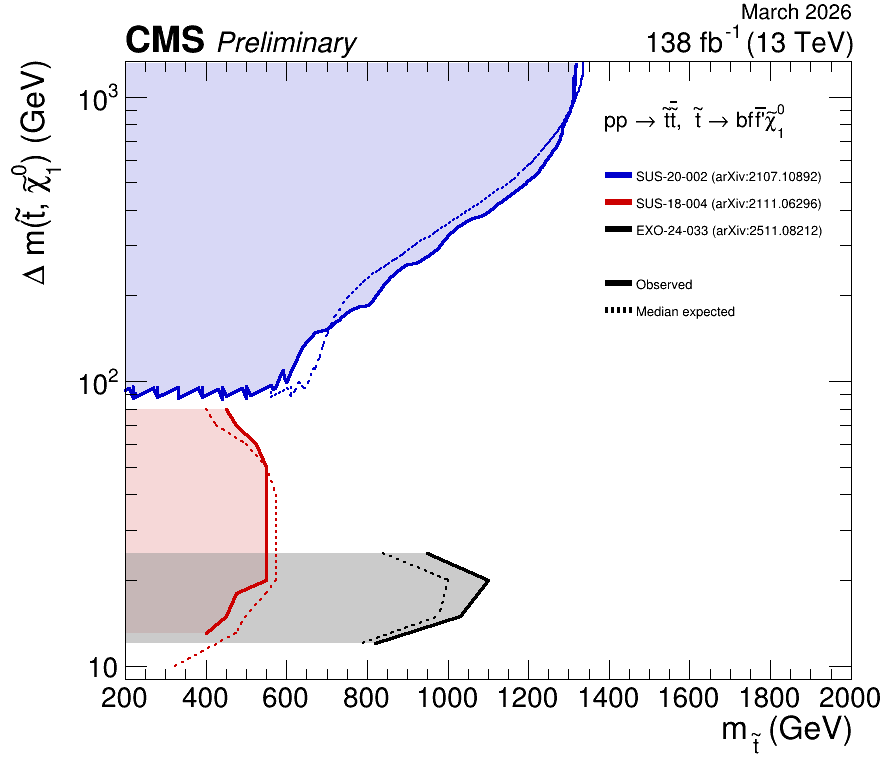

In [196]:
import ROOT
import numpy as np
from array import array

ROOT.gROOT.SetBatch(True)

# --- global style tweaks (CMS-like) ---
ROOT.gStyle.SetOptStat(0)
ROOT.gStyle.SetPadTickX(1)
ROOT.gStyle.SetPadTickY(1)

def make_graph(x, y, sort=2):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    m = np.isfinite(x) & np.isfinite(y)
    x = x[m]
    y = y[m]

    if sort == 2:
        order = np.argsort(y)  # important for proper polygon
    elif sort == 1:
        order = np.argsort(x)  # important for proper polygon

    x = x[order]
    y = y[order]

    return ROOT.TGraph(len(x), array("d", x.tolist()), array("d", y.tolist()))

def make_left_exclusion(graph, xmin):
    """
    Create filled polygon for region LEFT of curve.
    """
    n = graph.GetN()

    xs = [graph.GetPointX(i) for i in range(n)]
    ys = [graph.GetPointY(i) for i in range(n)]

    x0, y0 = xs[0], ys[0]
    x1, y1 = xs[-1], ys[-1]

    poly_x = [xmin, x0] + xs + [xmin, xmin]
    poly_y = [y0,   y0] + ys + [y1,   y0]

    return ROOT.TGraph(len(poly_x),
                       array("d", poly_x),
                       array("d", poly_y))


# --- build graphs ---
g_sus20002_obs = make_graph(
    sus_20_002_obs['m_{stop} [GeV]'],
    sus_20_002_obs['\\DeltaM [GeV]'],
    sort=1
)

g_exo24033_obs = make_graph(
    exo_24_033_obs['Observed $m$ excluded at 95%% CL [GeV]'],
    exo_24_033_obs['$\Delta m$ [GeV]'],
    sort=2
)

g_sus18004_obs = make_graph(
    sus_18_004_obs_max[r'$m_{\tilde{\text{t}}}$ [GeV]'],
    sus_18_004_obs_max[r'$\Delta m (\tilde{\text{t}}, \tilde{\chi}^0_1)$ [GeV]'],
    sort=2
)

g_sus20002_exp = make_graph(
    sus_20_002_exp['m_{stop} [GeV]'],
    sus_20_002_exp['\\DeltaM [GeV]'],
    sort=1
)

g_exo24033_exp = make_graph(
    exo_24_033_exp['Median expected $m$ excluded at 95%% CL [GeV]'],
    exo_24_033_exp['$\Delta m$ [GeV]'],
    sort=2
)

g_sus18004_exp = make_graph(
    sus_18_004_exp_max[r'$m_{\tilde{\text{t}}}$ [GeV]'],
    sus_18_004_exp_max[r'$\Delta m (\tilde{\text{t}}, \tilde{\chi}^0_1)$ [GeV]'],
    sort=2
)



# --- style ---
g_sus20002_obs.SetLineColor(ROOT.kBlue+1)
g_sus20002_obs.SetLineWidth(3)

g_exo24033_obs.SetLineColor(ROOT.kBlack)
g_exo24033_obs.SetLineWidth(3)

g_sus18004_obs.SetLineColor(ROOT.kRed+1)
g_sus18004_obs.SetLineWidth(3)

g_sus20002_exp.SetLineColor(ROOT.kBlue+1)
g_sus20002_exp.SetLineWidth(2)
g_sus20002_exp.SetLineStyle(2)

g_exo24033_exp.SetLineColor(ROOT.kBlack)
g_exo24033_exp.SetLineWidth(2)
g_exo24033_exp.SetLineStyle(2)

g_sus18004_exp.SetLineColor(ROOT.kRed+1)
g_sus18004_exp.SetLineWidth(2)
g_sus18004_exp.SetLineStyle(2)


# --- canvas ---
c = ROOT.TCanvas("c","",900,800)
c.SetLogy()

c.SetLeftMargin(0.14)
c.SetRightMargin(0.05)
c.SetTopMargin(0.08)
c.SetBottomMargin(0.12)

xmin, xmax = 200, 2000
ymin, ymax = 9, 1330

# --- frame ---
frame = ROOT.TH1F("frame","",100,xmin,xmax)
frame.SetMinimum(ymin)
frame.SetMaximum(ymax)

frame.GetXaxis().SetTitle("m_{ #tilde{t}} (GeV)")
frame.GetYaxis().SetTitle("#Delta m(#tilde{t}, #tilde{#chi}^{0}_{1}) (GeV)")

frame.GetXaxis().SetTitleSize(0.045)
frame.GetYaxis().SetTitleSize(0.045)
frame.GetXaxis().SetLabelSize(0.04)
frame.GetYaxis().SetLabelSize(0.04)

frame.GetYaxis().SetTitleOffset(1.4)

frame.Draw()


# --- shaded exclusion regions ---
h_sus20002 = make_left_exclusion(g_sus20002_obs, xmin)
h_sus20002.SetFillColorAlpha(ROOT.kBlue+1,0.15)
h_sus20002.SetLineWidth(0)
h_sus20002.Draw("F SAME")

h_sus18004 = make_left_exclusion(g_sus18004_obs, xmin)
h_sus18004.SetFillColorAlpha(ROOT.kRed+1,0.15)
h_sus18004.SetLineWidth(0)
h_sus18004.Draw("F SAME")

h_exo24033 = make_left_exclusion(g_exo24033_obs, xmin)
# h_exo24033.SetFillStyle(3354)   # hatched
h_exo24033.SetFillColorAlpha(ROOT.kGray+1, 0.50)
h_exo24033.SetLineWidth(0)
h_exo24033.Draw("F SAME")


# --- draw curves ---
g_sus20002_obs.Draw("L SAME")
g_sus18004_obs.Draw("L SAME")
g_exo24033_obs.Draw("L SAME")

# --- draw curves ---
g_sus20002_exp.Draw("L SAME")
g_sus18004_exp.Draw("L SAME")
g_exo24033_exp.Draw("L SAME")


# --- legend ---
# dummy objects for legend
leg_sus20002 = ROOT.TLine()
leg_sus20002.SetLineColor(ROOT.kBlue+1)
leg_sus20002.SetLineWidth(6)

leg_sus18004 = ROOT.TLine()
leg_sus18004.SetLineColor(ROOT.kRed+1)
leg_sus18004.SetLineWidth(6)

leg_exo24033 = ROOT.TLine()
leg_exo24033.SetLineColor(ROOT.kBlack)
leg_exo24033.SetLineWidth(6)

leg_obs = ROOT.TLine()
leg_obs.SetLineColor(ROOT.kBlack)
leg_obs.SetLineWidth(6)
leg_obs.SetLineStyle(1)

leg_exp = ROOT.TLine()
leg_exp.SetLineColor(ROOT.kBlack)
leg_exp.SetLineWidth(6)
leg_exp.SetLineStyle(2)

# legend
leg = ROOT.TLegend(0.67,0.58,0.94,0.79)
leg.SetBorderSize(0)
leg.SetFillColor(ROOT.kWhite)

leg.AddEntry(leg_sus20002, "SUS-20-002 (arXiv:2107.10892)", "l")
leg.AddEntry(leg_sus18004, "SUS-18-004 (arXiv:2111.06296)", "l")
leg.AddEntry(leg_exo24033, "EXO-24-033 (arXiv:2511.08212)", "l")

# spacer
leg.AddEntry(0, "", "")

# line-style explanation
leg.AddEntry(leg_obs, "Observed", "l")
leg.AddEntry(leg_exp, "Median expected", "l")



leg.SetMargin(0.15)
leg.Draw()


# --- CMS labels ---
latex = ROOT.TLatex()
latex.SetNDC()

latex.SetTextFont(62)
latex.SetTextSize(0.05)
latex.DrawLatex(0.14,0.932,"CMS")

latex.SetTextFont(52)
latex.SetTextSize(0.04)
latex.DrawLatex(0.24,0.932,"Preliminary")

latex.SetTextFont(42)
latex.SetTextSize(0.04)
latex.DrawLatex(0.72,0.932,"138 fb^{-1} (13 TeV)")

latex.SetTextFont(42)
latex.SetTextSize(0.03)
latex.DrawLatex(0.828,0.975,"March 2026")

latex.SetTextFont(42)
latex.SetTextSize(0.03)
latex.DrawLatex(0.675,0.835,"pp #rightarrow #tilde{t}#bar{#tilde{t}},  #tilde{t} #rightarrow bf#bar{f'}#tilde{#chi}^{0}_{1}")


c.RedrawAxis()
c.Update()
c.Draw()